In [ ]:
from google.colab import auth
auth.authenticate_user()
print('Authenticated Successfully!')

Authenticated Successfully!


In [ ]:
#Save your project ID in variable named 'my_project'
my_project = "smooth-research-491306-f7"

In [ ]:
%%bigquery df --project smooth-research-491306-f7
WITH team_scores AS (
  SELECT
   match_id,
   batting_team,
   SUM(runs_of_bat + extras) AS total_score
 FROM `smooth-research-491306-f7.ipl_kaggle_coursera_project.kl rahul`
GROUP BY match_id,batting_team),
winners AS (
  SELECT
  t1.match_id,
  CASE WHEN t1.total_score > t2.total_score THEN t1.batting_team
  WHEN t2.total_score > t1.total_score THEN t2.batting_team
  ELSE 'Tie'
  END AS winning_team
  FROM team_scores t1
  JOIN team_scores t2 ON t1.match_id = t2.match_id AND t1.batting_team < t2.batting_team
)
  SELECT
  CASE WHEN w.winning_team = 'DC' THEN 'Won' ELSE 'Lost' END AS match_result,
  SUM(t.runs_of_bat) AS total_runs,
  COUNT(CASE WHEN t.wide = 0 OR T.wide IS NULL THEN 1 END) AS balls_faced,
  ROUND(SAFE_DIVIDE(SUM(t.runs_of_bat),
  COUNT(CASE WHEN t.wide = 0 OR t.wide IS NULL THEN 1 END))*100,2) AS strike_rate
    FROM `smooth-research-491306-f7.ipl_kaggle_coursera_project.kl rahul` AS  t
  JOIN
    winners AS w ON t.match_id = w.match_id
    WHERE
    t.striker = 'Rahul'
    GROUP BY
    match_result

Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
print(df)

  match_result  total_runs  balls_faced  strike_rate
0          Won          58           38       152.63
1         Lost         387          208       186.06


<Figure size 640x480 with 0 Axes>

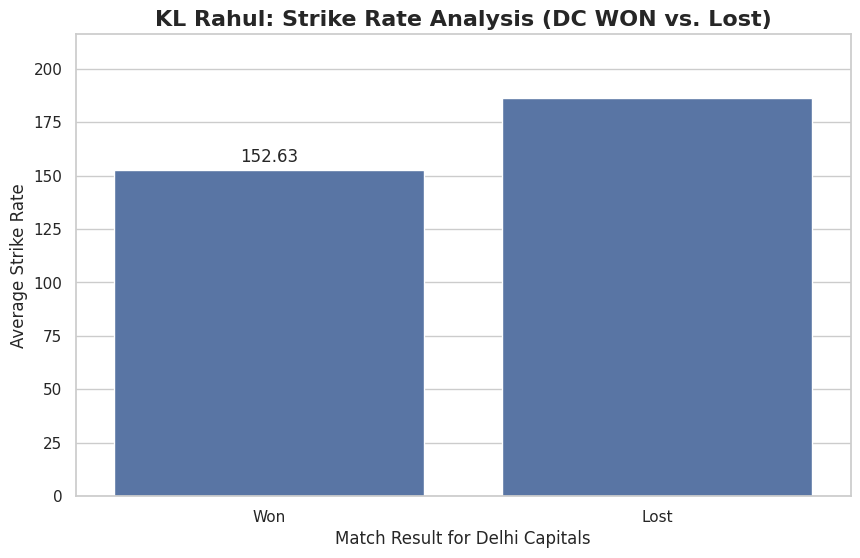

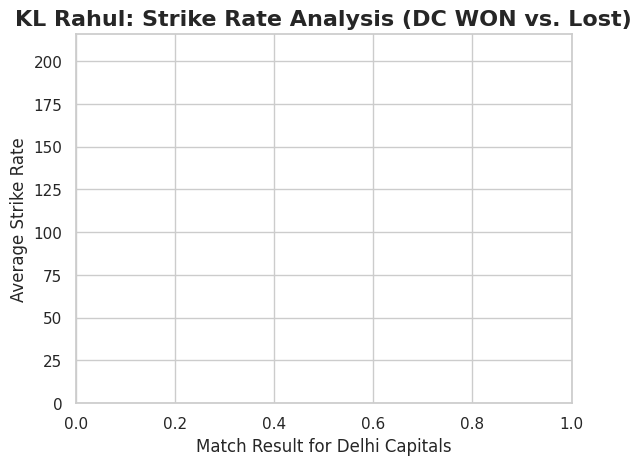

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.clf()
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="match_result", y="strike_rate", data=df)
for p in ax.patches:
  ax.annotate(format(p.get_height(),'.2f'),
              (p.get_x() + p.get_width() / 2., p.get_height()),
              ha = 'center', va = 'center',
              xytext = (0,9),
              textcoords = 'offset points')

  plt.title("KL Rahul: Strike Rate Analysis (DC WON vs. Lost)",fontsize=16,fontweight='bold')
  plt.xlabel("Match Result for Delhi Capitals",fontsize=12)
  plt.ylabel("Average Strike Rate",fontsize=12)
  plt.ylim(0, df['strike_rate'].max()+ 30)

  plt.show()